# Subfase 7b — PCA analysis

In [17]:
import json
from pathlib import Path

from bvg_core.config import GLOBAL_SEED
from bvg_core.utils import load_manifest, require_file

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


In [18]:
PROJECT_ROOT = Path.cwd().resolve().parent
DATASET_PATH = PROJECT_ROOT / 'data' / 'processed' / 'BVG_features_svc_master.csv'
MODELS_DIR = PROJECT_ROOT / 'models' / 'quantum'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'fase4_comparativa'

# Slice 2: exportar outputs y actualizar manifests.
EXPORT_RESULTS = True
UPDATE_MANIFESTS = True

DATE_COL = 'fecha'
COMPANY_COL = 'empresa'
TARGET_COL = 'target_up_h5'

EXCLUDE = {
    DATE_COL, COMPANY_COL,
    'target_up_h1', 'target_up_h5', 'target_up_h20',
    'ret_fwd_h1', 'ret_fwd_h5', 'ret_fwd_h20',
}

def discover_manifests(models_dir: Path) -> list[dict]:
    pattern = '*_h5_manifest.json'
    manifests = sorted(models_dir.glob(pattern))
    if not manifests:
        raise FileNotFoundError(f'No se encontraron manifests en {models_dir} (pattern={pattern})')

    records = []
    for manifest_path in manifests:
        manifest = load_manifest(manifest_path)
        prefix = manifest_path.name.replace('_manifest.json', '')
        company = manifest.get('company') or prefix.replace('_', ' ')

        scaler_path = models_dir / f'{prefix}_scaler.joblib'
        pca_path = models_dir / f'{prefix}_pca.joblib'
        require_file(scaler_path)
        require_file(pca_path)

        records.append({
            'company': company,
            'prefix': prefix,
            'manifest_path': manifest_path,
            'manifest': manifest,
            'scaler_path': scaler_path,
            'pca_path': pca_path,
        })
    return records


In [19]:
require_file(DATASET_PATH)
df = pd.read_csv(DATASET_PATH)

required_cols = {DATE_COL, COMPANY_COL, TARGET_COL}
missing = sorted(required_cols.difference(df.columns))
if missing:
    raise ValueError(f'Columnas faltantes: {missing}')

df = df.loc[df[TARGET_COL].notna()].copy()
if df.empty:
    raise ValueError('Dataset vacío tras filtrar target_up_h5.')

feature_cols = [c for c in df.columns if c not in EXCLUDE]
if not feature_cols:
    raise ValueError('No se pudieron inferir feature_cols.')

df = df.assign(**{DATE_COL: pd.to_datetime(df[DATE_COL], errors='coerce')})
df = df.dropna(subset=feature_cols + [TARGET_COL, DATE_COL, COMPANY_COL]).copy()
if df.empty:
    raise ValueError('Dataset vacío tras limpieza de NaN.')

df = df.sort_values([COMPANY_COL, DATE_COL], kind='stable').reset_index(drop=True)
{
    'rows': int(len(df)),
    'companies': sorted(df[COMPANY_COL].unique().tolist()),
    'feature_cols': len(feature_cols),
}


{'rows': 2831,
 'companies': ['BANCO GUAYAQUIL S.A.', 'CORPORACION FAVORITA C.A.'],
 'feature_cols': 24}

In [20]:
manifest_records = discover_manifests(MODELS_DIR)
{
    'manifests': len(manifest_records),
    'companies': [rec['company'] for rec in manifest_records],
}


{'manifests': 2,
 'companies': ['BANCO GUAYAQUIL S.A.', 'CORPORACION FAVORITA C.A.']}

In [21]:
summary_rows = []
company_payloads = {}

for rec in manifest_records:
    company = rec['company']
    prefix = rec['prefix']

    scaler = joblib.load(rec['scaler_path'])
    pca = joblib.load(rec['pca_path'])

    if not hasattr(pca, 'explained_variance_ratio_'):
        raise ValueError(f"PCA sin explained_variance_ratio_: {rec['pca_path']}")

    variance = np.array(pca.explained_variance_ratio_, dtype=float)
    if variance.size < 5:
        raise ValueError(f"PCA con menos de 5 componentes: {rec['pca_path']}")

    ratio5 = variance[:5]
    cumsum5 = np.cumsum(ratio5)

    summary_rows.append({
        'company': company,
        'model_name': prefix,
        'pca_n_components': int(getattr(pca, 'n_components_', len(variance))),
        'explained_variance_ratio': ratio5.tolist(),
        'explained_variance_cumsum': cumsum5.tolist(),
    })

    df_company = df.loc[df[COMPANY_COL] == company].copy()
    if df_company.empty:
        raise ValueError(f'Sin datos para empresa: {company}')

    X_company = df_company.loc[:, feature_cols].copy()
    X_scaled = scaler.transform(X_company)
    if X_scaled.shape[1] < 10:
        raise ValueError(f'Features insuficientes para PCA exploratorio (n=10): {X_scaled.shape[1]}')

    exploratory_pca = PCA(n_components=10, random_state=GLOBAL_SEED)
    exploratory_pca.fit(X_scaled)

    company_payloads[company] = {
        'prefix': prefix,
        'variance_ratio': ratio5,
        'variance_cumsum': cumsum5,
        'exploratory_ratio': exploratory_pca.explained_variance_ratio_,
        'exploratory_cumsum': np.cumsum(exploratory_pca.explained_variance_ratio_),
        'n_features_total': int(X_scaled.shape[1]),
    }

summary_df = pd.DataFrame(summary_rows)
summary_df


,company,model_name,pca_n_components,explained_variance_ratio,explained_variance_cumsum
0,BANCO GUAYAQUIL S.A.,BANCO_GUAYAQUIL_SA_h5,5,"[0.9089813973808708, 0.032923792510340034, 0.0...","[0.9089813973808708, 0.9419051898912109, 0.958..."
1,CORPORACION FAVORITA C.A.,CORPORACION_FAVORITA_CA_h5,5,"[0.427456694455552, 0.23154634774503902, 0.119...","[0.427456694455552, 0.659003042200591, 0.77894..."


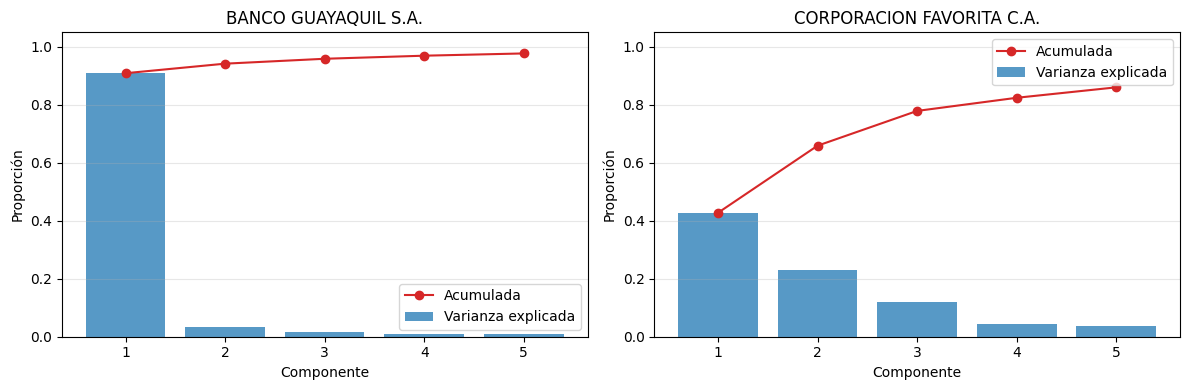

In [22]:
companies = list(company_payloads.keys())
n_companies = len(companies)

fig, axes = plt.subplots(1, n_companies, figsize=(6 * n_companies, 4), sharey=False, layout='constrained')
if n_companies == 1:
    axes = [axes]

for ax, company in zip(axes, companies):
    payload = company_payloads[company]
    ratio = payload['variance_ratio']
    cumsum = payload['variance_cumsum']

    x = np.arange(1, len(ratio) + 1)
    ax.bar(x, ratio, alpha=0.75, label='Varianza explicada')
    ax.plot(x, cumsum, color='tab:red', marker='o', label='Acumulada')
    ax.set_title(company)
    ax.set_xlabel('Componente')
    ax.set_ylabel('Proporción')
    ax.set_ylim(0, 1.05)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend(loc='best')

if EXPORT_RESULTS:
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    out_path = RESULTS_DIR / 'BVG_pca_scree_plot.png'
    fig.savefig(out_path, dpi=150, bbox_inches='tight')


In [23]:
if EXPORT_RESULTS:
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    csv_path = RESULTS_DIR / 'BVG_pca_varianza_explicada.csv'
    summary_df.to_csv(csv_path, index=False)
    csv_path
else:
    summary_df.head()


In [24]:
if UPDATE_MANIFESTS:
    for rec in manifest_records:
        manifest = load_manifest(rec['manifest_path'])
        if not isinstance(manifest, dict):
            raise ValueError(f"Manifest inválido (no dict): {rec['manifest_path']}")

        company = rec['company']
        payload = company_payloads.get(company)
        if payload is None:
            raise ValueError(f'No se encontró payload para empresa: {company}')

        manifest['pca_explained_variance'] = {
            'per_component': payload['variance_ratio'].tolist(),
            'cumulative_5': payload['variance_cumsum'].tolist(),
            'n_features_total': payload['n_features_total'],
            'variance_components_6_to_10': payload['exploratory_ratio'][5:10].tolist(),
        }
        rec['manifest_path'].write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding='utf-8')

    'Manifests actualizados.'
else:
    'UPDATE_MANIFESTS=False → no se escribieron manifests.'
